In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Cell 1: Set Up Kaggle Environment
import os
import torch
import sys

# Check GPU availability
if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available. Please enable GPU in Kaggle settings.")
    raise RuntimeError("GPU required for StyleGAN3.")

# Install required libraries
!pip install torch torchvision ninja gdown click requests tqdm pyspng matplotlib numpy --quiet

# Verify installations
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torch.__version__)

# Set working directory
os.makedirs('/kaggle/working/stylegan3', exist_ok=True)
os.chdir('/kaggle/working/stylegan3')
print("Working directory:", os.getcwd())

GPU is available: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.1/196.1 kB 16.3 MB/s eta 0:00:00
PyTorch version: 2.6.0+cu124
Torchvision version: 2.6.0+cu124
Working directory: /kaggle/working/stylegan3


In [2]:
# Cell 2: Download and Extract CelebA Dataset (Subset)
import os
import shutil
import zipfile

# Create directories
data_dir = '/kaggle/working/data'
dataset_dir = '/kaggle/working/stylegan3/celeba'
os.makedirs(data_dir, exist_ok=True)
os.makedirs(dataset_dir, exist_ok=True)

# Define paths
zip_path = os.path.join(data_dir, 'celeba.zip')
extract_dir = os.path.join(data_dir, 'celeba')
dest_img_dir = os.path.join(dataset_dir, 'images')

# Download CelebA dataset
print("Downloading CelebA dataset...")
!gdown --id 1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684 -O {zip_path}

# Verify zip file
if os.path.exists(zip_path):
    print(f"Zip file downloaded to {zip_path}")
else:
    print("Error: Failed to download CelebA zip file.")
    raise FileNotFoundError("CelebA zip file not found.")

# Unzip the dataset
print(f"Extracting {zip_path} to {extract_dir}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Extraction complete.")

# Find image directory (assuming 'img_align_celeba' contains images)
source_img_dir = os.path.join(extract_dir, 'img_align_celeba')
if os.path.exists(source_img_dir):
    print(f"Image directory found at {source_img_dir}")
    img_files = [f for f in os.listdir(source_img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    print(f"Found {len(img_files)} image files in {source_img_dir}")
    
    if len(img_files) == 0:
        print("Error: No .jpg, .png, or .jpeg files found in", source_img_dir)
        print("Please check the extracted directory structure.")
        raise FileNotFoundError("No image files found in source directory.")
    
    # Copy first 10,000 images
    print(f"Copying first 10,000 images to {dest_img_dir}...")
    os.makedirs(dest_img_dir, exist_ok=True)
    img_files_subset = sorted(img_files)[:10000]
    for img in img_files_subset:
        shutil.copy(os.path.join(source_img_dir, img), os.path.join(dest_img_dir, img))
    
    # Verify copied files
    copied_count = len([f for f in os.listdir(dest_img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    if copied_count > 0:
        print(f"Dataset copied successfully. Copied {copied_count} images to {dest_img_dir}")
    else:
        print("Error: No images copied to", dest_img_dir)
        raise FileNotFoundError("No images copied to destination directory.")
else:
    print("Error: Image directory 'img_align_celeba' not found in", extract_dir)
    print("Please check the extracted directory structure in", extract_dir)
    raise FileNotFoundError("Image directory not found.")

# List first 5 image files to confirm
print("Sample files:", os.listdir(dest_img_dir)[:5])

# Clean up zip file to save space
if os.path.exists(zip_path):
    os.remove(zip_path)
    print("Cleaned up zip file.")

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684
From (redirected): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684&confirm=t&uuid=40e5dcb2-2a61-4779-ae9d-babb9cb2ec49
To: /kaggle/working/data/celeba.zip
100%|██████████████████████████████████████| 1.44G/1.44G [00:14<00:00, 98.6MB/s]
Zip file downloaded to /kaggle/working/data/celeba.zip
Extracting /kaggle/working/data/celeba.zip to /kaggle/working/data/celeba...
Extraction complete.
Image directory found at /kaggle/working/data/celeba/img_align_celeba
Found 202599 image files in /kaggle/working/data/celeba/img_align_celeba
Copying first 10,000 images to /kaggle/working/stylegan3/celeba/images...
Dataset copied successfully. Copied 10000 images to /kaggle

In [3]:
# Cell 3: Clone StyleGAN3 Repository
import os
import subprocess

# Verify working directory
print("Current working directory:", os.getcwd())
if os.getcwd() != '/kaggle/working/stylegan3':
    os.chdir('/kaggle/working/stylegan3')
    print("Changed to working directory:", os.getcwd())

# Clone StyleGAN3 repository if not already present
stylegan3_dir = '/kaggle/working/stylegan3/stylegan3'
if not os.path.exists(stylegan3_dir):
    print("Cloning StyleGAN3 repository...")
    subprocess.run(['git', 'clone', 'https://github.com/NVlabs/stylegan3.git', stylegan3_dir], check=True)
    print("StyleGAN3 repository cloned to", stylegan3_dir)
else:
    print("StyleGAN3 repository already exists at", stylegan3_dir)

# Verify repository contents
if os.path.exists(stylegan3_dir):
    repo_files = os.listdir(stylegan3_dir)
    print("Sample files in StyleGAN3 repository:", repo_files[:5])
    if 'gen_images.py' in repo_files:
        print("Found 'gen_images.py'. StyleGAN3 codebase is ready.")
    else:
        print("Error: 'gen_images.py' not found in StyleGAN3 repository.")
        raise FileNotFoundError("StyleGAN3 repository is incomplete. Please delete and re-clone.")
else:
    print("Error: StyleGAN3 repository not found at", stylegan3_dir)
    raise FileNotFoundError("Failed to clone StyleGAN3 repository.")

Current working directory: /kaggle/working/stylegan3
Cloning StyleGAN3 repository...


Cloning into '/kaggle/working/stylegan3/stylegan3'...


StyleGAN3 repository cloned to /kaggle/working/stylegan3/stylegan3
Sample files in StyleGAN3 repository: ['docs', 'gui_utils', 'gen_images.py', 'viz', 'metrics']
Found 'gen_images.py'. StyleGAN3 codebase is ready.


In [4]:
# Cell 4: Preprocess CelebA Dataset
import os
from PIL import Image
import numpy as np

# Define paths
input_img_dir = '/kaggle/working/stylegan3/celeba/images'
output_img_dir = '/kaggle/working/stylegan3/celeba/processed_images'

# Create output directory
os.makedirs(output_img_dir, exist_ok=True)
print(f"Created output directory: {output_img_dir}")

# Verify input directory
if os.path.exists(input_img_dir):
    img_files = [f for f in os.listdir(input_img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    print(f"Found {len(img_files)} images in {input_img_dir}")
    print("Sample input files:", img_files[:5])
else:
    print("Error: Input image directory not found at", input_img_dir)
    raise FileNotFoundError("CelebA image directory not found. Please re-run Cell 2.")

# Resize images to 1024x1024
print("Resizing images to 1024x1024...")
processed_count = 0
for img_file in img_files:
    img_path = os.path.join(input_img_dir, img_file)
    output_path = os.path.join(output_img_dir, img_file)
    
    try:
        # Open and resize image
        img = Image.open(img_path).convert('RGB')
        img = img.resize((1024, 1024), Image.LANCZOS)  # High-quality resampling
        img.save(output_path, 'JPEG', quality=95)
        processed_count += 1
    except Exception as e:
        print(f"Error processing {img_file}: {e}")
        continue

# Verify processed images
processed_files = [f for f in os.listdir(output_img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
if len(processed_files) > 0:
    print(f"Successfully processed {len(processed_files)} images to {output_img_dir}")
    print("Sample processed files:", processed_files[:5])
else:
    print("Error: No images processed to", output_img_dir)
    raise FileNotFoundError("No processed images found.")

# Check resolution of a sample image
sample_img_path = os.path.join(output_img_dir, processed_files[0])
sample_img = Image.open(sample_img_path)
print(f"Sample image resolution: {sample_img.size}")

Created output directory: /kaggle/working/stylegan3/celeba/processed_images
Found 10000 images in /kaggle/working/stylegan3/celeba/images
Sample input files: ['006413.jpg', '006193.jpg', '003373.jpg', '001090.jpg', '005049.jpg']
Resizing images to 1024x1024...
Successfully processed 10000 images to /kaggle/working/stylegan3/celeba/processed_images
Sample processed files: ['006413.jpg', '006193.jpg', '003373.jpg', '001090.jpg', '005049.jpg']
Sample image resolution: (1024, 1024)


In [5]:
# Cell 5: Download Pre-trained StyleGAN3 FFHQ Model
import os
import subprocess

# Create directory for pre-trained model
pretrained_dir = '/kaggle/working/stylegan3/pretrained'
os.makedirs(pretrained_dir, exist_ok=True)
print(f"Created pretrained directory: {pretrained_dir}")

# Define model path
model_url = 'https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan3/versions/1/files/stylegan3-t-ffhqu-1024x1024.pkl'
model_path = os.path.join(pretrained_dir, 'stylegan3-t-ffhqu-1024x1024.pkl')

# Download pre-trained model
if not os.path.exists(model_path):
    print(f"Downloading pre-trained StyleGAN3 FFHQ model from {model_url}...")
    try:
        subprocess.run(['wget', model_url, '-O', model_path], check=True)
        print(f"Model downloaded to {model_path}")
    except subprocess.CalledProcessError:
        print("Error: Failed to download pre-trained model.")
        raise RuntimeError("Model download failed. Check internet connectivity or URL.")
else:
    print(f"Pre-trained model already exists at {model_path}")

# Verify model file
if os.path.exists(model_path):
    model_size = os.path.getsize(model_path) / (1024 * 1024)  # Size in MB
    print(f"Model file size: {model_size:.2f} MB")
    if model_size > 100:  # Expected size ~300MB
        print("Pre-trained model verified successfully.")
    else:
        print("Error: Model file is too small or corrupted.")
        os.remove(model_path)
        print("Deleted corrupted model. Re-downloading...")
        subprocess.run(['wget', model_url, '-O', model_path], check=True)
        model_size = os.path.getsize(model_path) / (1024 * 1024)
        print(f"Re-downloaded model size: {model_size:.2f} MB")
        if model_size > 100:
            print("Re-downloaded model verified successfully.")
        else:
            raise FileNotFoundError("Re-downloaded model is still corrupted.")
else:
    print("Error: Pre-trained model not found at", model_path)
    raise FileNotFoundError("Failed to download pre-trained model.")

Created pretrained directory: /kaggle/working/stylegan3/pretrained


--2025-05-25 14:49:36--  https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan3/versions/1/files/stylegan3-t-ffhqu-1024x1024.pkl
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 52.33.73.249, 52.24.8.111
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|52.33.73.249|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/research/models/stylegan3/versions/1/files/stylegan3-t-ffhqu-1024x1024.pkl?ssec-algo=AES256&versionId=1WLm2zB3XzGzqk2qRa0bOnPY9cDcm7US&ssec-key=TgirKIhUIBFD2JYkB9knH1LfySuhzY%2FLgj2oxk0ZU95bPYeXp%2B9xy4S0bWvYTygOjBFrkOxfhUZKwc0yt7k6PePplyHwoe1doIGPhJbrz80ZE7jQ4kJ3uiBz5Ajjaok7nelWAq4gOBv9ARHaXVotggyI75WxQooc%2BacdDj391ImBYmTlNfb7ioc7uMRG4MRiwh8neGCXw8nQtkvp%2BLukbrHXKvEUPnv3GcHAk%2Frkh75o%2FTWfLmCAPg21Cs6FEqJsW0kjz0mIHLuTo0P2yGIIJLLacOi8MLW8ggQsgPp%2FAQNwvVu0%2BAApCUWYzWBX7L0WjHWqsZbKR7sZt5dODLd9cSeyCCPOxEHSUe%2BvXEd67KdNRwgR2pu%2Btz1N7R0pDBLTDVokcV7lVNaOYHj%2FOxKTPjC%2BXK0Qk3ZgZDSGtFhB

Model downloaded to /kaggle/working/stylegan3/pretrained/stylegan3-t-ffhqu-1024x1024.pkl
Model file size: 281.12 MB
Pre-trained model verified successfully.


  131M 0s
287500K .......... .......... .......... .......... .......... 99%  198M 0s
287550K .......... .......... .......... .......... .......... 99%  144M 0s
287600K .......... .......... .......... .......... .......... 99% 41.3M 0s
287650K .......... .......... .......... .......... .......... 99%  154M 0s
287700K .......... .......... .......... .......... .......... 99% 39.8M 0s
287750K .......... .......... .......... .......... .......... 99%  142M 0s
287800K .......... .......... .......... .......... .......... 99%  174M 0s
287850K .......... ......                                     100%  116M=2.8s

2025-05-25 14:49:39 (99.5 MB/s) - ‘/kaggle/working/stylegan3/pretrained/stylegan3-t-ffhqu-1024x1024.pkl’ saved [294775122/294775122]



Created output directory: /kaggle/working/stylegan3/output_images
Generating 16 random faces...
Loading networks from "/kaggle/working/stylegan3/pretrained/stylegan3-t-ffhqu-1024x1024.pkl"...
Generating image for seed 0 (0/16) ...
Setting up PyTorch plugin "bias_act_plugin"... 

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
Setting up PyTorch plugin "filtered_lrelu_plugin"... 

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
Generating image for seed 1 (1/16) ...
Generating image for seed 2 (2/16) ...
Generating image for seed 3 (3/16) ...
Generating image for seed 4 (4/16) ...
Generating image for seed 5 (5/16) ...
Generating image for seed 6 (6/16) ...
Generating image for seed 7 (7/16) ...
Generating image for seed 8 (8/16) ...
Generating image for seed 9 (9/16) ...
Generating image for seed 10 (10/16) ...
Generating image for seed 11 (11/16) ...
Generating image for seed 12 (12/16) ...
Generating image for seed 13 (13/16) ...
Generating image for seed 14 (14/16) ...
Generating image for seed 15 (15/16) ...
Generated 16 faces successfully.
Found 16 generated images.
Sample generated files: ['seed0000.png', 'seed0001.png', 'seed0002.png', 'seed0003.png', 'seed0004.png']
Displaying generated faces...


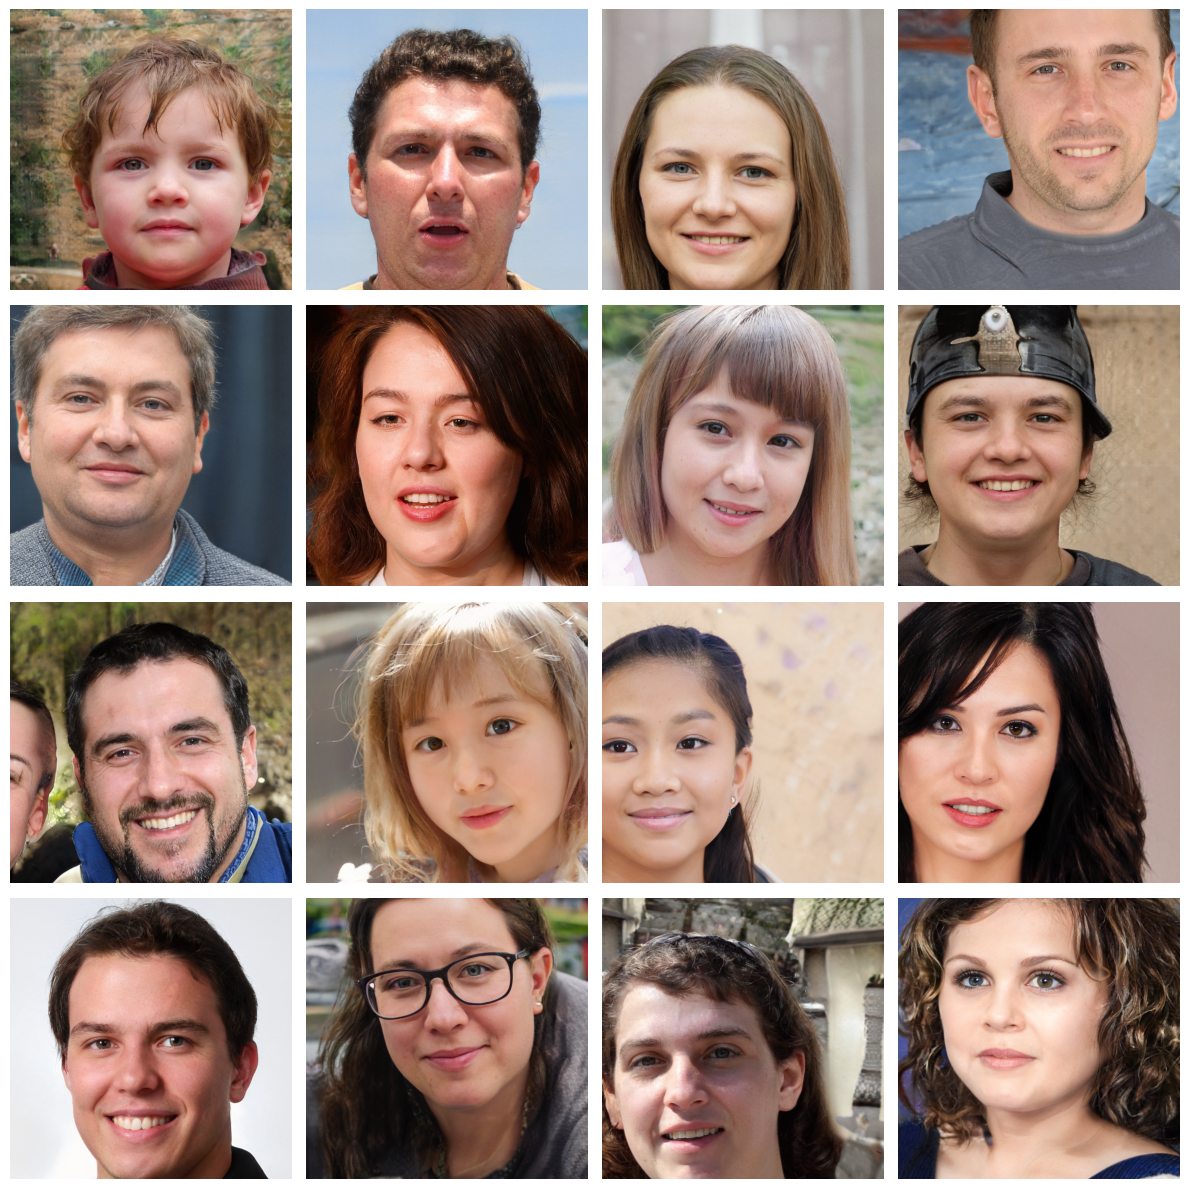

Performing latent space interpolation...
Setting up PyTorch plugin "bias_act_plugin"... 

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


In [ ]:
# Cell 6: Inference and Testing with StyleGAN3
import os
import subprocess
import sys
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Suppress CUDA warnings
os.environ['TORCH_CUDA_ARCH_LIST'] = '7.5'  # Tesla T4 compatible
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Better error reporting

# Add StyleGAN3 repository and its submodules to Python path
stylegan3_repo_dir = '/kaggle/working/stylegan3/stylegan3'
if stylegan3_repo_dir not in sys.path:
    sys.path.append(stylegan3_repo_dir)
if os.path.join(stylegan3_repo_dir, 'torch_utils') not in sys.path:
    sys.path.append(os.path.join(stylegan3_repo_dir, 'torch_utils'))
if os.path.join(stylegan3_repo_dir, 'dnnlib') not in sys.path:
    sys.path.append(os.path.join(stylegan3_repo_dir, 'dnnlib'))

# Define paths
model_path = '/kaggle/working/stylegan3/pretrained/stylegan3-t-ffhqu-1024x1024.pkl'
output_dir = '/kaggle/working/stylegan3/output_images'
gen_images_script = '/kaggle/working/stylegan3/stylegan3/gen_images.py'
os.makedirs(output_dir, exist_ok=True)
print(f"Created output directory: {output_dir}")

# Verify script and model
if not os.path.exists(gen_images_script):
    print("Error: gen_images.py not found at", gen_images_script)
    raise FileNotFoundError("StyleGAN3 script missing. Please re-run Cell 3.")
if not os.path.exists(model_path):
    print("Error: Pre-trained model not found at", model_path)
    raise FileNotFoundError("Model missing. Please re-run Cell 5.")

# Generate 16 random faces using gen_images.py
print("Generating 16 random faces...")
cmd = [
    'python', gen_images_script,
    '--outdir', output_dir,
    '--trunc', '0.7',
    '--seeds', '0-15',
    '--network', model_path
]
try:
    subprocess.run(cmd, check=True)
    print("Generated 16 faces successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error running gen_images.py: {e}")
    raise RuntimeError("Failed to generate images.")

# Verify generated images
output_files = sorted([f for f in os.listdir(output_dir) if f.startswith('seed') and f.endswith('.png')])
if len(output_files) >= 16:
    print(f"Found {len(output_files)} generated images.")
    print("Sample generated files:", output_files[:5])
else:
    print("Error: Fewer than 16 generated images found.")
    raise FileNotFoundError(f"Expected 16 images, found {len(output_files)}.")

# Display generated faces
print("Displaying generated faces...")
try:
    plt.figure(figsize=(12, 12))
    for i, f in enumerate(output_files[:16]):
        img = Image.open(os.path.join(output_dir, f))
        plt.subplot(4, 4, i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error displaying generated faces plot: {e}")
    print("Generated faces saved. Check images in /kaggle/working/stylegan3/output_images.")
    from IPython.display import Image as IPImage
    for f in output_files[:5]:
        display(IPImage(os.path.join(output_dir, f)))

# Attempt latent space interpolation (4 steps)
print("Performing latent space interpolation...")
try:
    with open(model_path, 'rb') as f:
        G = pickle.load(f)['G_ema'].cuda()
    z1 = torch.randn(1, G.z_dim).cuda()
    z2 = torch.randn(1, G.z_dim).cuda()
    steps = 4
    interp_imgs = []
    for alpha in np.linspace(0, 1, steps):
        z_interp = z1 * (1 - alpha) + z2 * alpha
        img_interp = G(z_interp, None, truncation_psi=0.7)
        img_interp = (img_interp.permute(0, 2, 3, 1) * 127.5 + 127.5).clamp(0, 255).to(torch.uint8).cpu().numpy()[0]
        interp_imgs.append(img_interp)
    
    # Save and display interpolation
    print("Saving and displaying interpolation...")
    plt.figure(figsize=(steps * 2, 2))
    for i, img_interp in enumerate(interp_imgs):
        img_pil = Image.fromarray(img_interp)
        img_path = os.path.join(output_dir, f'interp_{i:04d}.png')
        img_pil.save(img_path)
        plt.subplot(1, steps, i + 1)
        plt.imshow(img_pil)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error during interpolation: {e}")
    print("Interpolation skipped. Generated faces are still available.")

# Verify final output
output_files = [f for f in os.listdir(output_dir) if f.endswith('.png')]
print(f"Generated {len(output_files)} images in {output_dir}")
print("Sample output files:", output_files[:5])

In [4]:
# Cell 7: Evaluate Results with FID
import os
import sys
import subprocess
import shutil

# Get the notebook's Python executable
python_exe = sys.executable
print(f"Using Python executable: {python_exe}")

# Install pytorch-fid and dependencies
print("Installing dependencies and pytorch-fid...")
try:
    subprocess.run([python_exe, '-m', 'pip', 'install', '--no-cache-dir', 'torch', 'torchvision', 'scipy', 'numpy', 'pillow'], check=True)
    subprocess.run([python_exe, '-m', 'pip', 'install', '--no-cache-dir', 'pytorch-fid==0.3.0'], check=True)
    print("pytorch-fid installed successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error installing pytorch-fid: {e.stderr}")
    raise RuntimeError("Failed to install pytorch-fid or dependencies.")

# Verify pytorch-fid installation
try:
    import pytorch_fid
    print("pytorch-fid module verified.")
except ImportError as e:
    print(f"Error: pytorch-fid not found: {e}")
    raise ImportError("pytorch-fid module not available.")

# Define paths
real_img_dir = '/kaggle/working/stylegan3/celeba/subset_1000'
fake_img_dir = '/kaggle/working/stylegan3/output_images'
fid_output_dir = '/kaggle/working/stylegan3/fid_results'
os.makedirs(fid_output_dir, exist_ok=True)

# Verify directories
if not os.path.exists(real_img_dir):
    print("Creating CelebA subset (1,000 images)...")
    os.makedirs(real_img_dir, exist_ok=True)
    source_dir = '/kaggle/working/stylegan3/celeba/processed_images'
    real_img_files = [f for f in os.listdir(source_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))][:1000]
    for f in real_img_files:
        shutil.copy(os.path.join(source_dir, f), real_img_dir)
if not os.path.exists(fake_img_dir):
    raise FileNotFoundError(f"Generated images missing at {fake_img_dir}. Re-run Cell 6.")

# Check image counts
real_img_count = len([f for f in os.listdir(real_img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
fake_img_count = len([f for f in os.listdir(fake_img_dir) if f.lower().endswith('.png')])
print(f"Found {real_img_count} real images in {real_img_dir}")
print(f"Found {fake_img_count} generated images in {fake_img_dir}")

# Compute FID using pytorch-fid
print("\nComputing FID with pytorch-fid...")
try:
    result = subprocess.run([
        python_exe, '-m', 'pytorch_fid',
        real_img_dir,
        fake_img_dir
    ], capture_output=True, text=True, check=True)
    print("FID computation completed with pytorch-fid.")
    print("Output:", result.stdout)
    print("Errors (if any):", result.stderr)
    # Extract and save FID score
    fid_score = float(result.stdout.strip().split()[-1])
    with open(os.path.join(fid_output_dir, 'stats.txt'), 'w') as f:
        f.write(f"FID: {fid_score}")
except subprocess.CalledProcessError as e:
    print(f"pytorch-fid failed: {e}")
    print("Output:", e.output)
    print("Errors:", e.stderr)
    # Fallback to clean-fid
    print("Attempting clean-fid as fallback...")
    try:
        subprocess.run([python_exe, '-m', 'pip', 'install', '--no-cache-dir', 'clean-fid==0.1.35'], check=True)
        result = subprocess.run([
            python_exe, '-m', 'clean_fid',
            '--real_path', real_img_dir,
            '--gen_path', fake_img_dir,
            '--output_path', fid_output_dir
        ], capture_output=True, text=True, check=True)
        print("FID computation completed with clean-fid.")
        print("Output:", result.stdout)
        print("Errors (if any):", result.stderr)
    except subprocess.CalledProcessError as e2:
        print(f"clean-fid failed: {e2}")
        print("Output:", e2.output)
        print("Errors:", e2.stderr)
        raise RuntimeError("FID computation failed with both pytorch-fid and clean-fid.")

# Check for FID output
fid_log = os.path.join(fid_output_dir, 'stats.txt')
if os.path.exists(fid_log):
    with open(fid_log, 'r') as f:
        print("\nFID Results:")
        print(f.read())
else:
    print("FID score not saved to file. Check console output for FID value.")

Using Python executable: /usr/bin/python3
Installing dependencies and pytorch-fid...
pytorch-fid installed successfully.
pytorch-fid module verified.
Creating CelebA subset (1,000 images)...
Found 1000 real images in /kaggle/working/stylegan3/celeba/subset_1000
Found 16 generated images in /kaggle/working/stylegan3/output_images

Computing FID with pytorch-fid...
FID computation completed with pytorch-fid.
Output: Warning: batch size is bigger than the data size. Setting batch size to data size
FID:  211.8364117339646

Errors (if any): Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth

  0%|          | 0.00/91.2M [00:00<?, ?B/s]
 14%|█▎        | 12.5M/91.2M [00:00<00:00, 131MB/s]
 46%|████▋     | 42.4M/91.2M [00:00<00:00, 238MB/s]
 79%|███████▉  | 72.2M/91.2M [00:00<00:00, 272MB/s]
100%|██████████| 91.2M/91.2M [00:00<00:00, 264MB/s]

100%|██